# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import time

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

In [3]:
start_time = time.time()

# **Loading the dataset**

In [4]:
base_df = pd.read_csv('SuperKart.csv')

In [5]:
# Checking to ensure the data loaded properly.
base_df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **Data Overview**

In [6]:
base_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
base_df.shape

(8763, 12)

In [8]:
duplicates = base_df[base_df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Product_Id, Product_Weight, Product_Sugar_Content, Product_Allocated_Area, Product_Type, Product_MRP, Store_Id, Store_Establishment_Year, Store_Size, Store_Location_City_Type, Store_Type, Product_Store_Sales_Total]
Index: []


In [9]:
count_unique = base_df['Product_Id'].nunique()
print(f"Number of unique Product_Id values: {count_unique}")

Number of unique Product_Id values: 8763


In [10]:
base_df.isnull().sum() 

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

In [11]:
num_cols = base_df.select_dtypes(include=['number']).columns.tolist()
print(num_cols)

['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']


In [12]:
cat_cols = base_df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['Product_Id', 'Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


An initial review of the dataset indicates that there are 8763 rows of data and these rows have 10 features (columns) with the 11th row being the target. There are no duplicate values and no data appears to be missing. The number of uniques product IDs is also 8763 so appearently no two stores sell the same product. This seems a bit odd to me. If true there may be an opportunity for store to trade ideas about what might sell between similar stores. If some of the products are same I think they should consider using common product IDs to improve ananlysis.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [13]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=True, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [14]:
base_df.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

## Product Weight

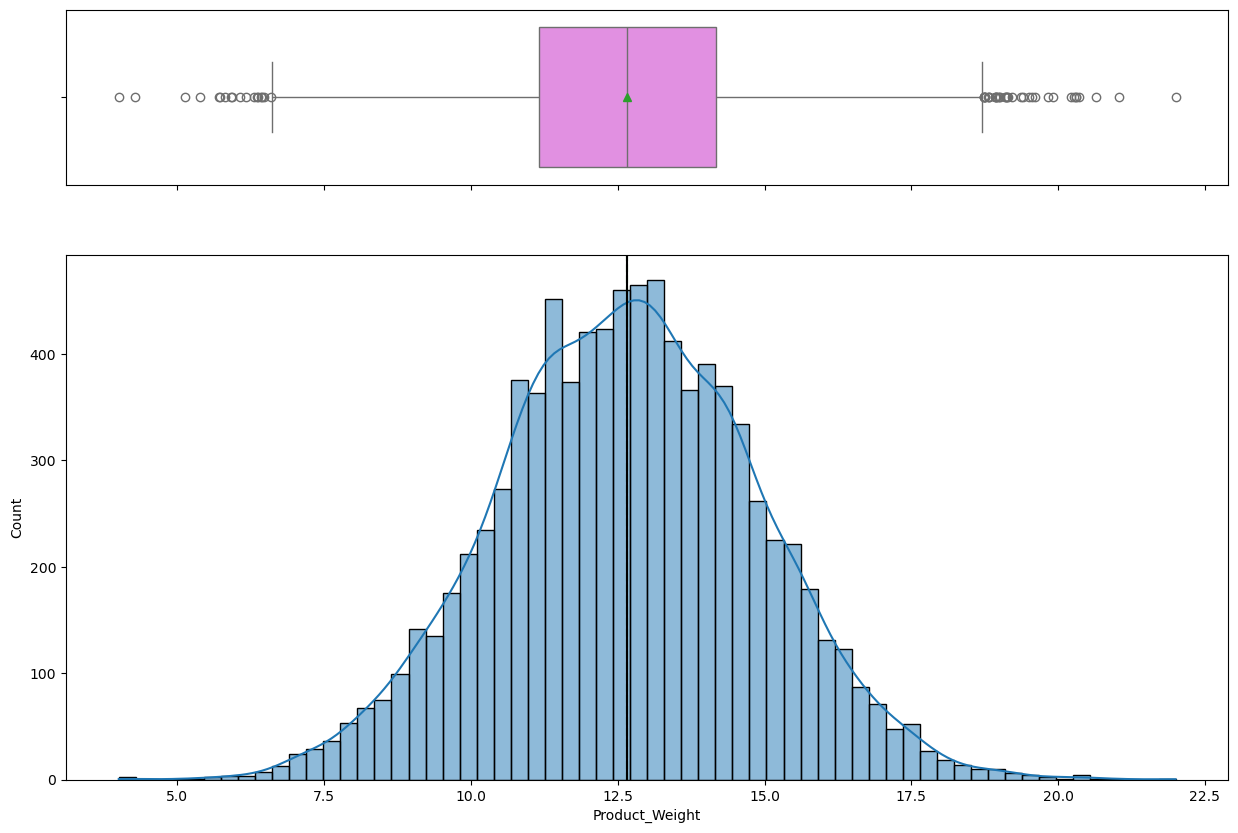

In [15]:
histogram_boxplot(data=base_df, feature='Product_Weight')

## Product Allocated Area

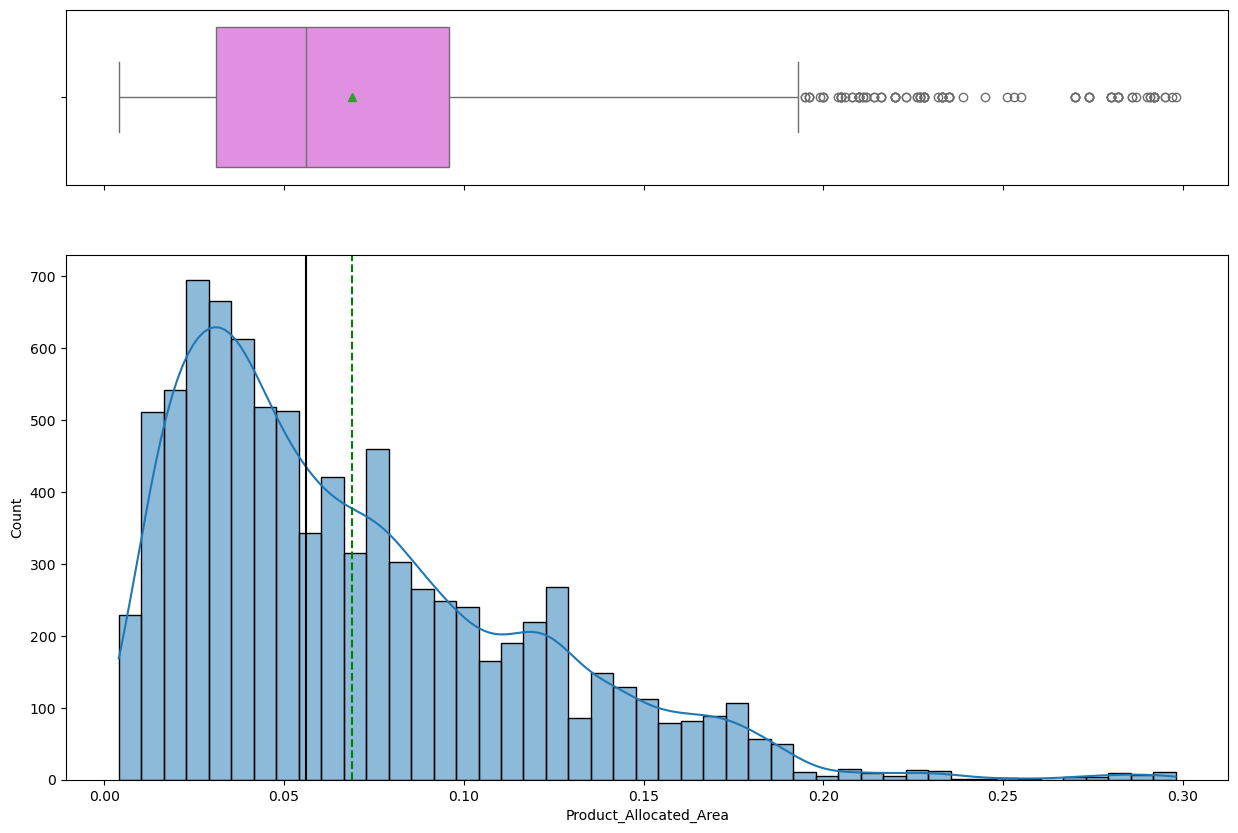

In [16]:
histogram_boxplot(data=base_df, feature='Product_Allocated_Area')

## Product MRP

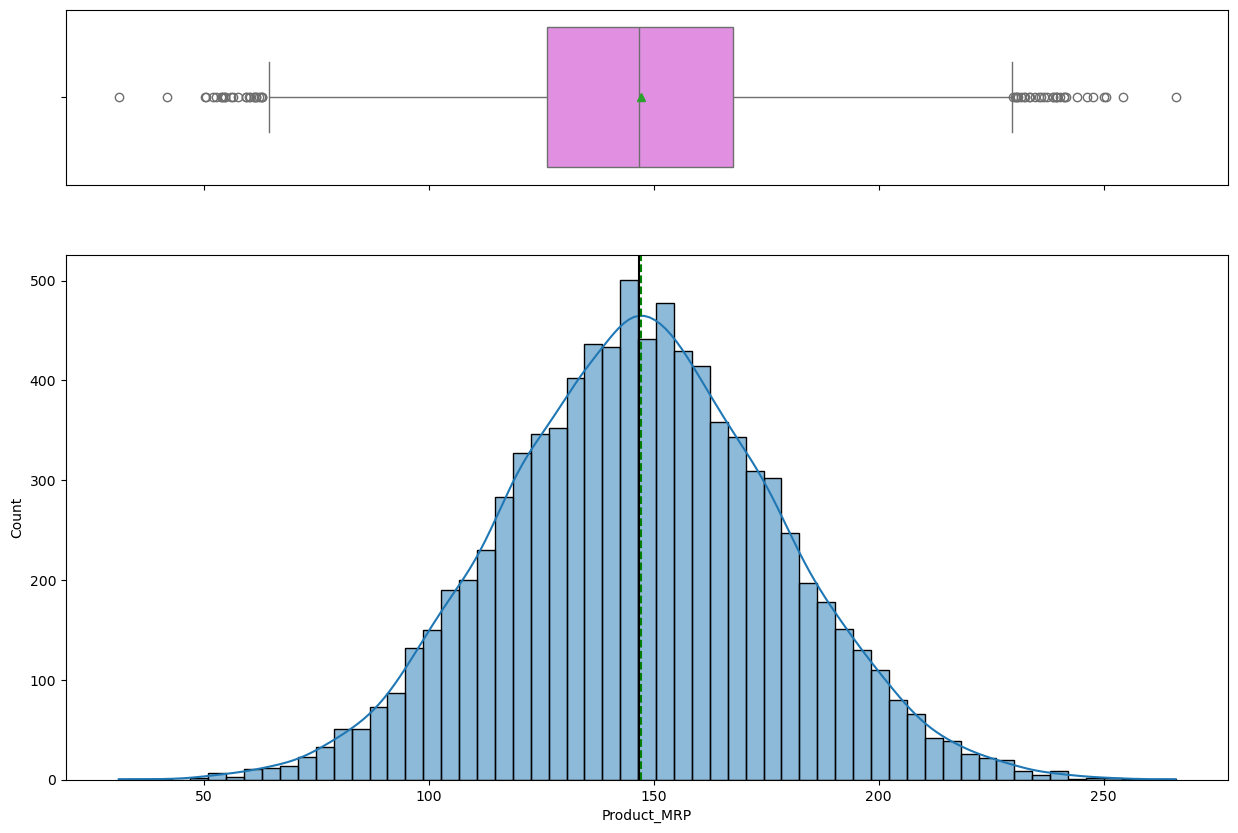

In [17]:
histogram_boxplot(data=base_df, feature='Product_MRP')

## Store Established Year

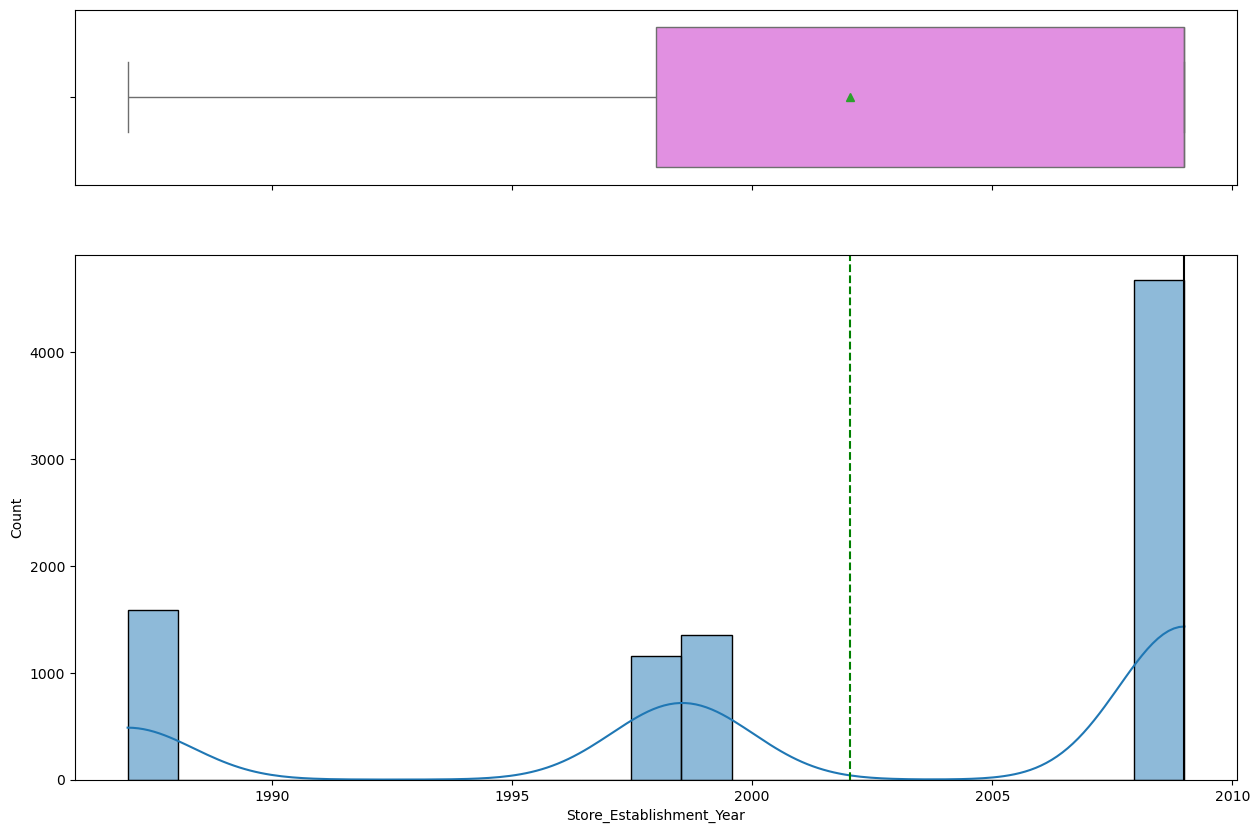

In [18]:
histogram_boxplot(data=base_df, feature='Store_Establishment_Year')

## Product Store Sales Total

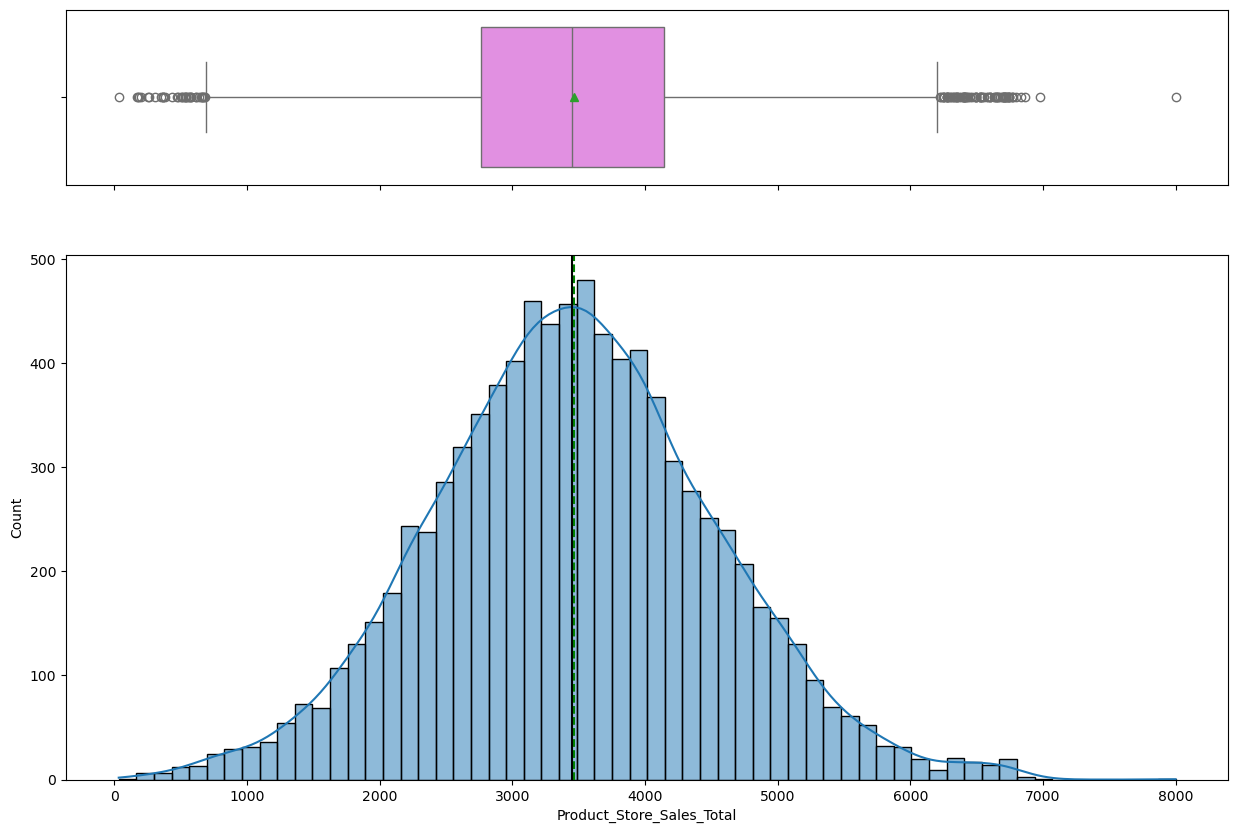

In [19]:
histogram_boxplot(data=base_df, feature='Product_Store_Sales_Total')

The univariate analysis of the numerical features indicates that most features have a number of outliers. These will be addressed in the data preparation stage. 

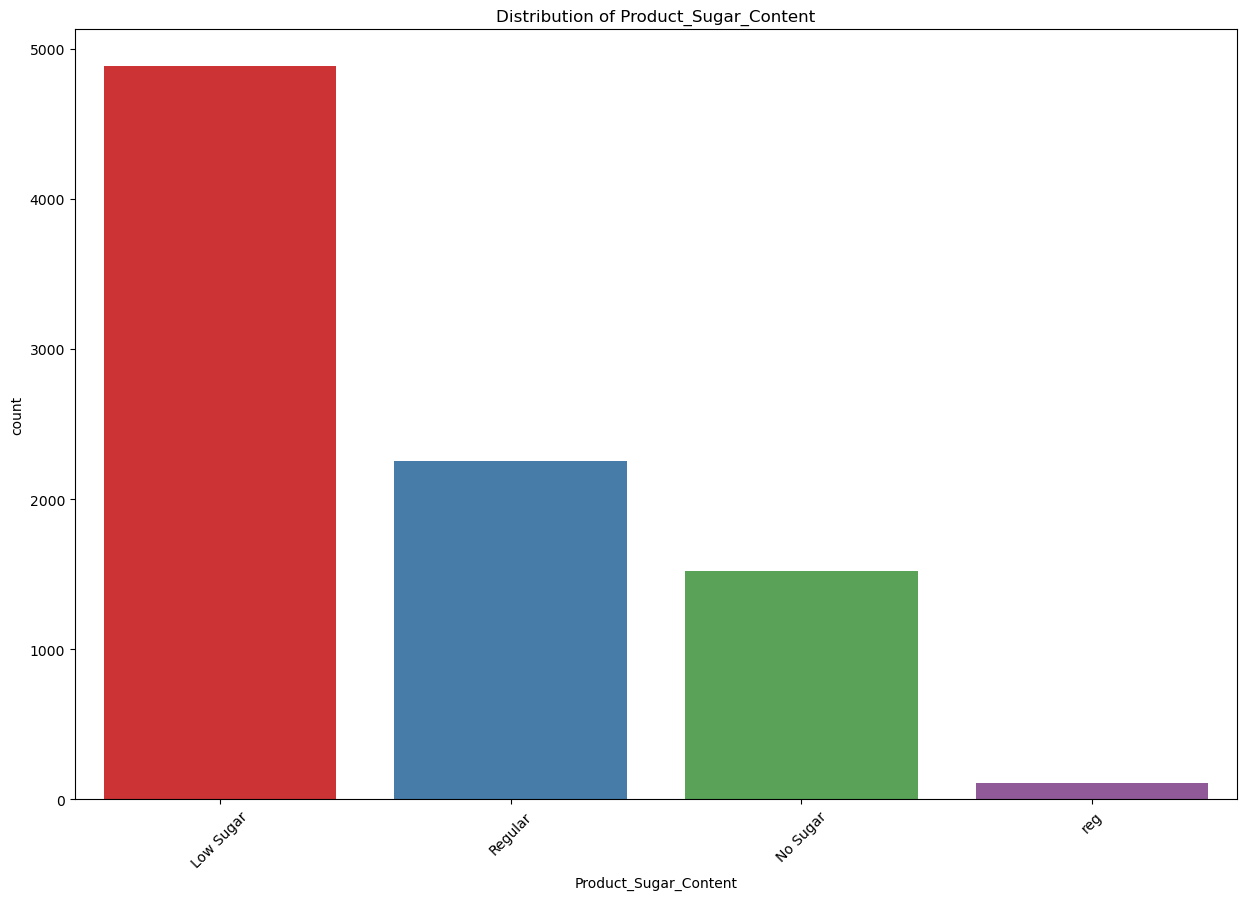

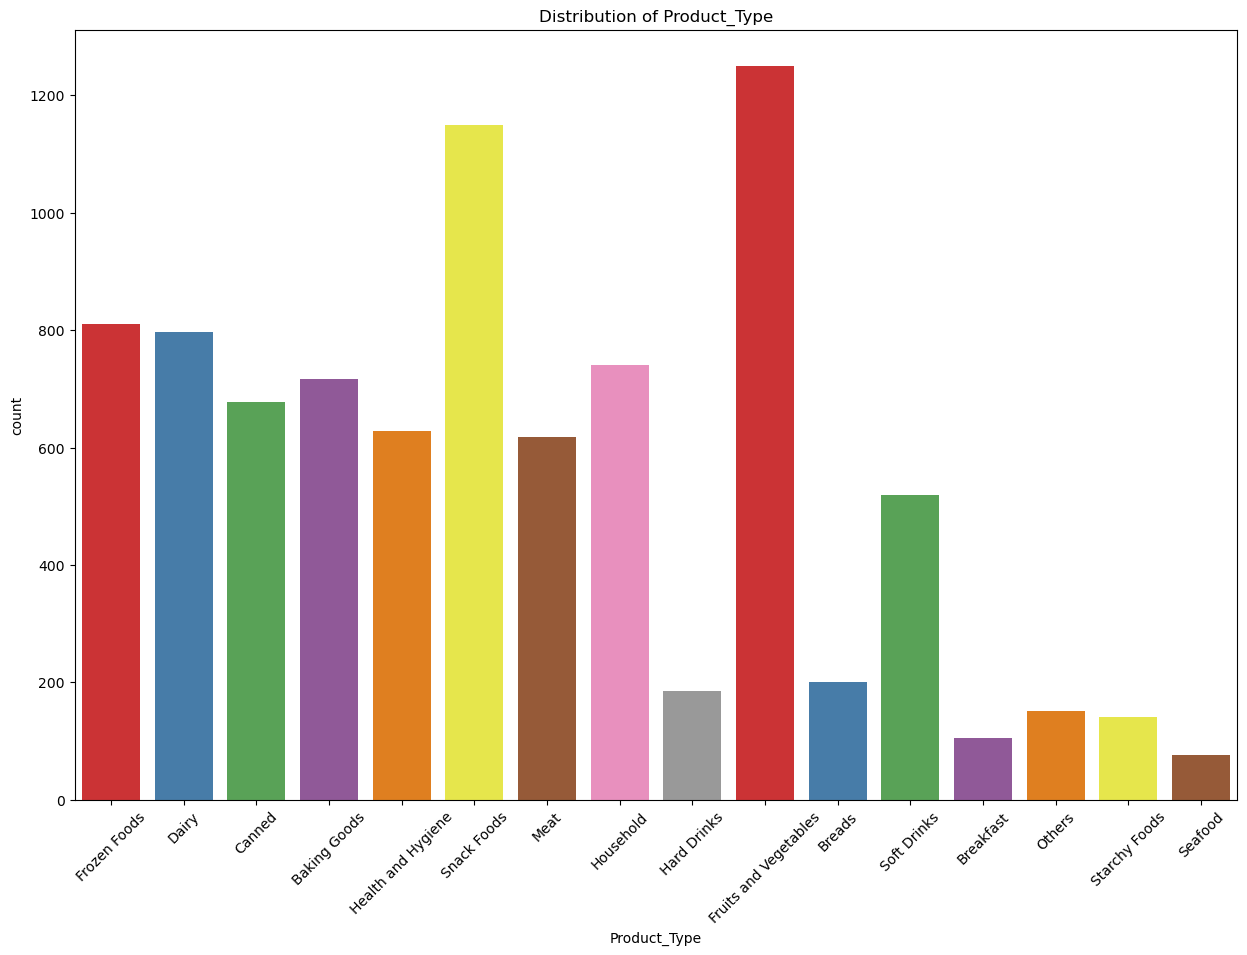

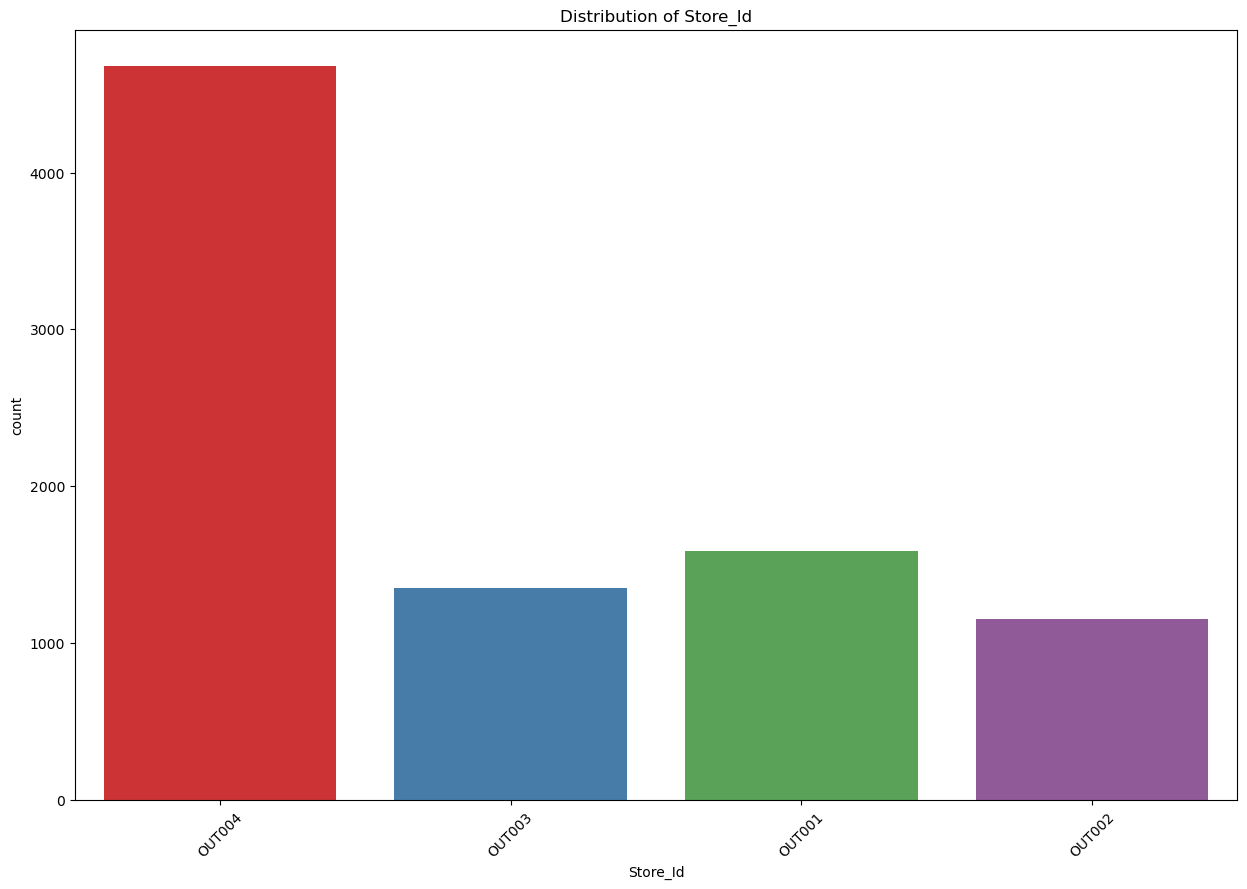

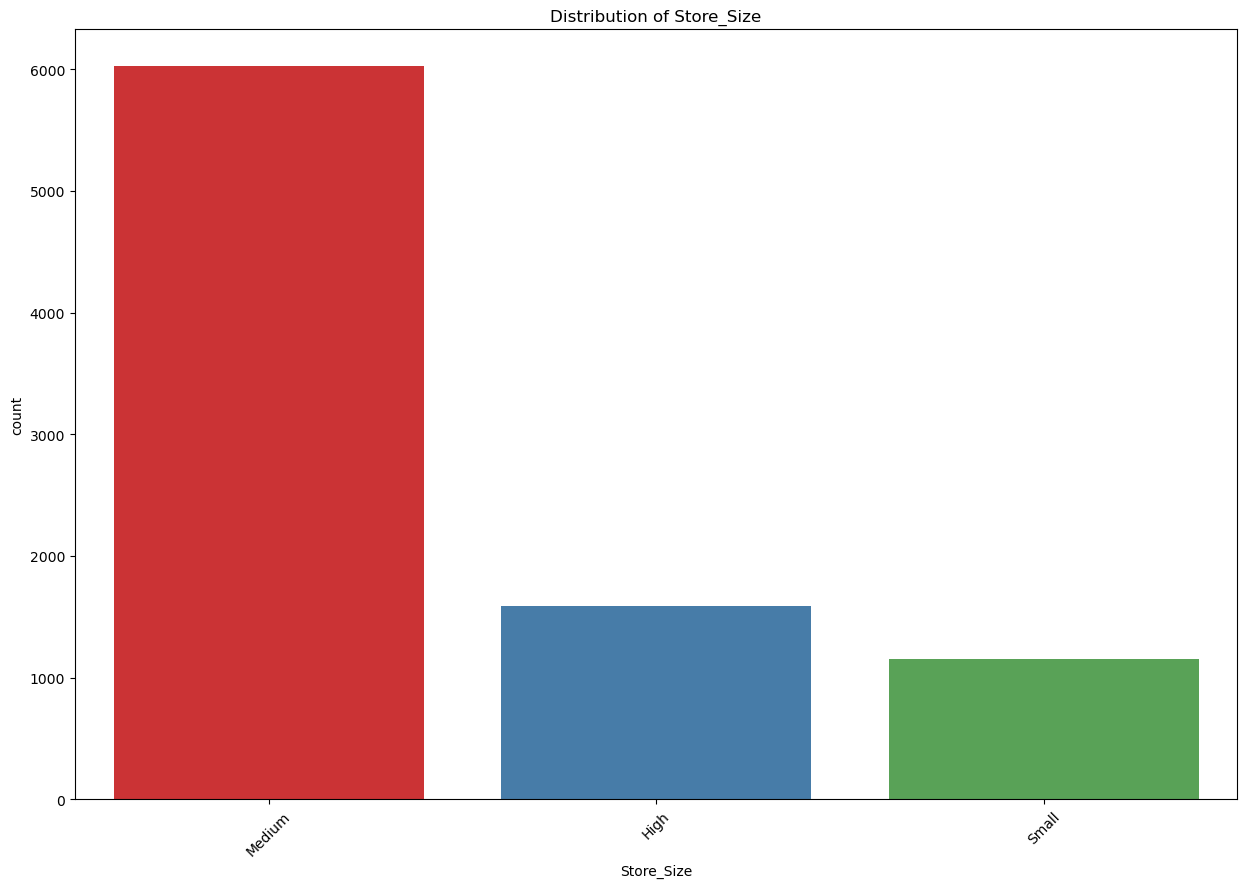

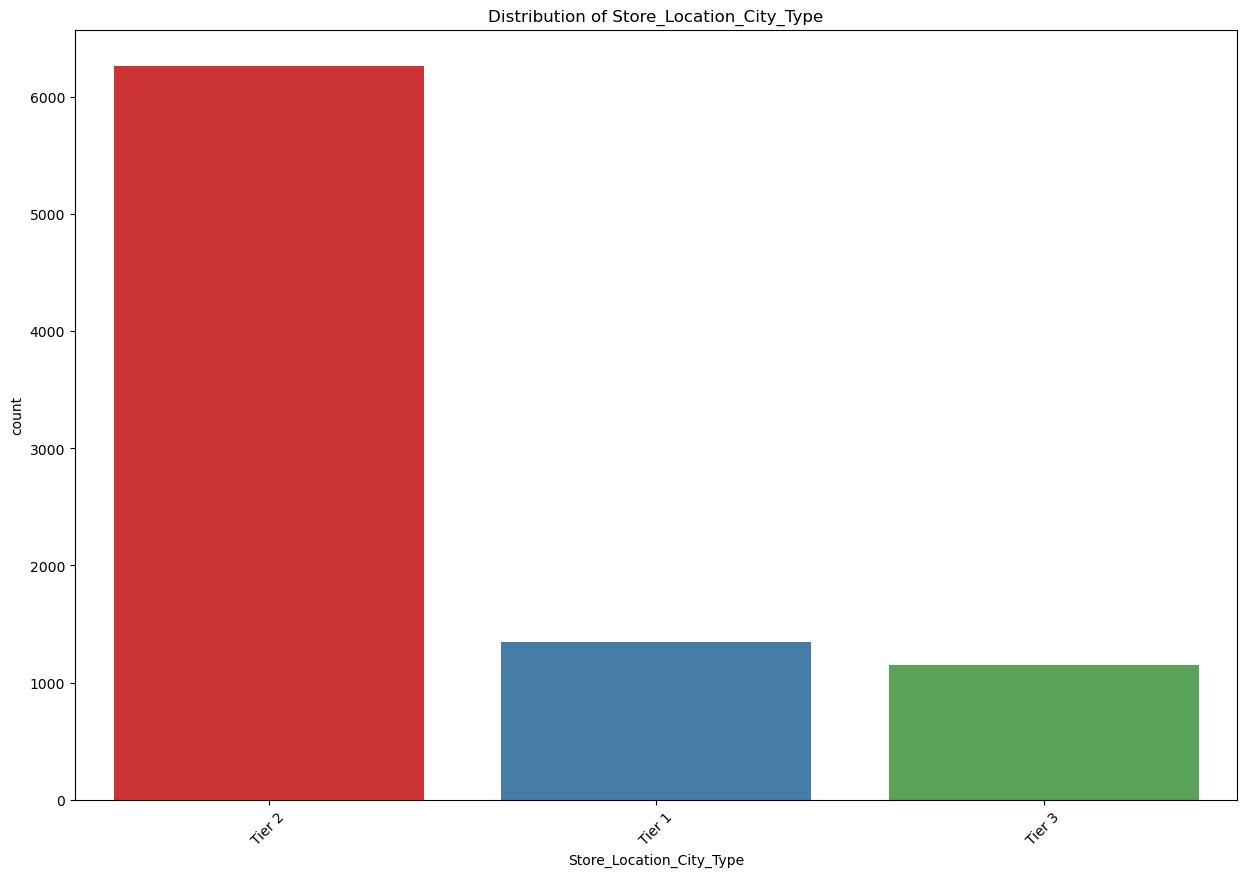

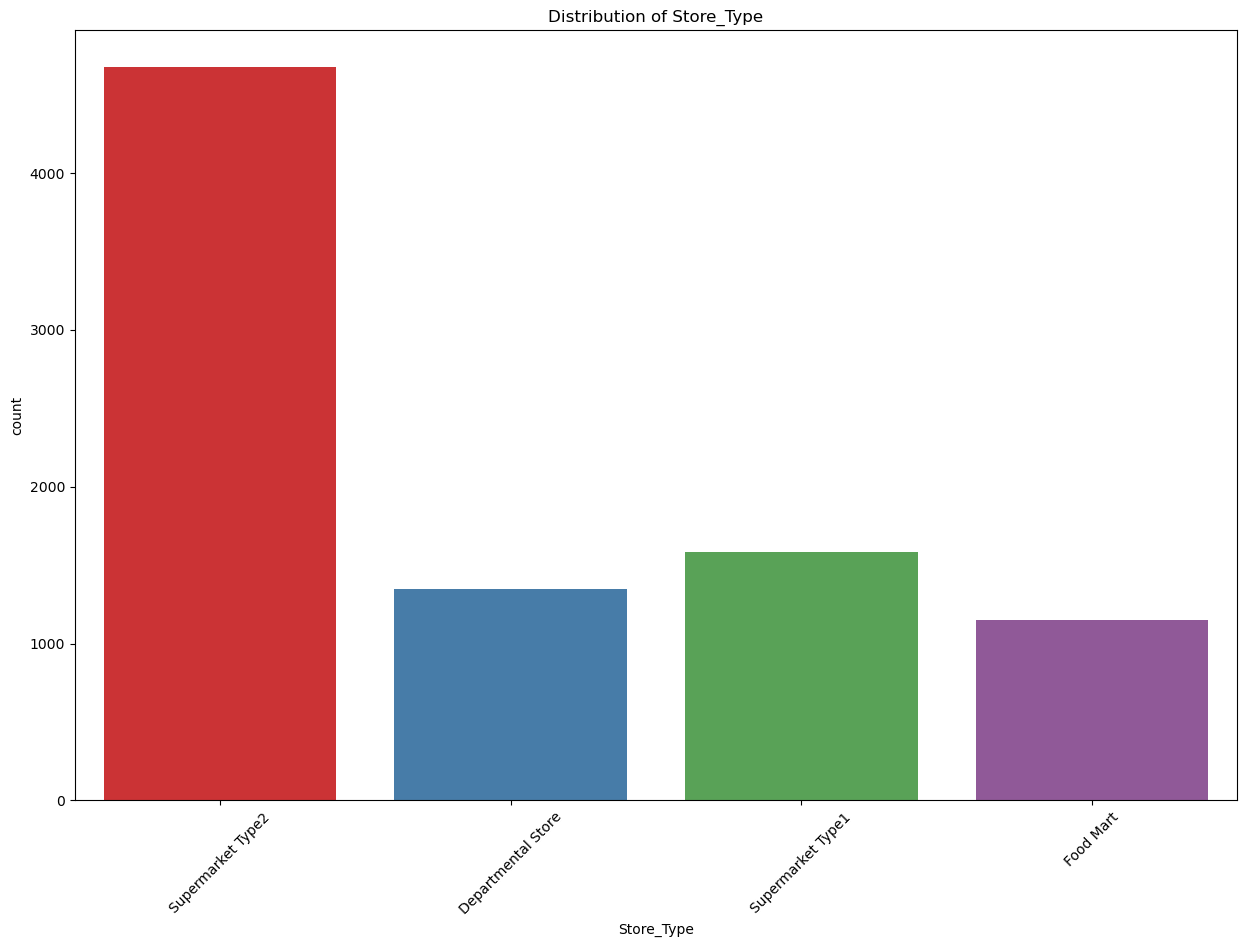

In [20]:
# For loop to plot all categorical features
cat_cols.pop(0) # needed to remove 'Product_ID'from these charts

for col in cat_cols:
    plt.figure(figsize=(15, 10))
    sns.countplot(data=base_df, x=col, palette="Set1")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

#### Categorical Feature Analysis
- In the sugar content feature we will need to combine the products with "Regular" and "reg"
- We will need to find a way to group the Product Type feature to reduce the number of categories
- The number and type of stores tend to be weighted quite heavly to medium, type 2 stores. We will need to see of revenue has the same distributiom

### Analysis of Sales by Store Type and Location

In [21]:
base_df.groupby('Store_Type')['Product_Store_Sales_Total'].mean().sort_values(ascending=False)

Store_Type
Departmental Store    4946.966323
Supermarket Type1     3923.778802
Supermarket Type2     3299.312111
Food Mart             1762.942465
Name: Product_Store_Sales_Total, dtype: float64

In [22]:
base_df.groupby('Store_Location_City_Type')['Product_Store_Sales_Total'].mean().sort_values(ascending=False)

Store_Location_City_Type
Tier 1    4946.966323
Tier 2    3457.473109
Tier 3    1762.942465
Name: Product_Store_Sales_Total, dtype: float64

In [23]:
base_df.groupby('Store_Size')['Product_Store_Sales_Total'].mean().sort_values(ascending=False)

Store_Size
High      3923.778802
Medium    3668.222573
Small     1762.942465
Name: Product_Store_Sales_Total, dtype: float64

In [24]:
base_df.groupby('Store_Id')['Product_Store_Sales_Total'].mean().sort_values(ascending=False)

Store_Id
OUT003    4946.966323
OUT001    3923.778802
OUT004    3299.312111
OUT002    1762.942465
Name: Product_Store_Sales_Total, dtype: float64

#### Analysis of Store Tpye and Location
- It appears that bigger is better and being in the better parts of town leads to higher total sales.
- Since the numbers are same I am going assumee that all of the Food Marts are in the Tier 3 areas and they are small stores. The company needs to evaluate this line of stores and determine if they want to continue going forward. It might be wise to see if they could spin these off. 

## Bivariate Analysis

### **Correlation Matrix**

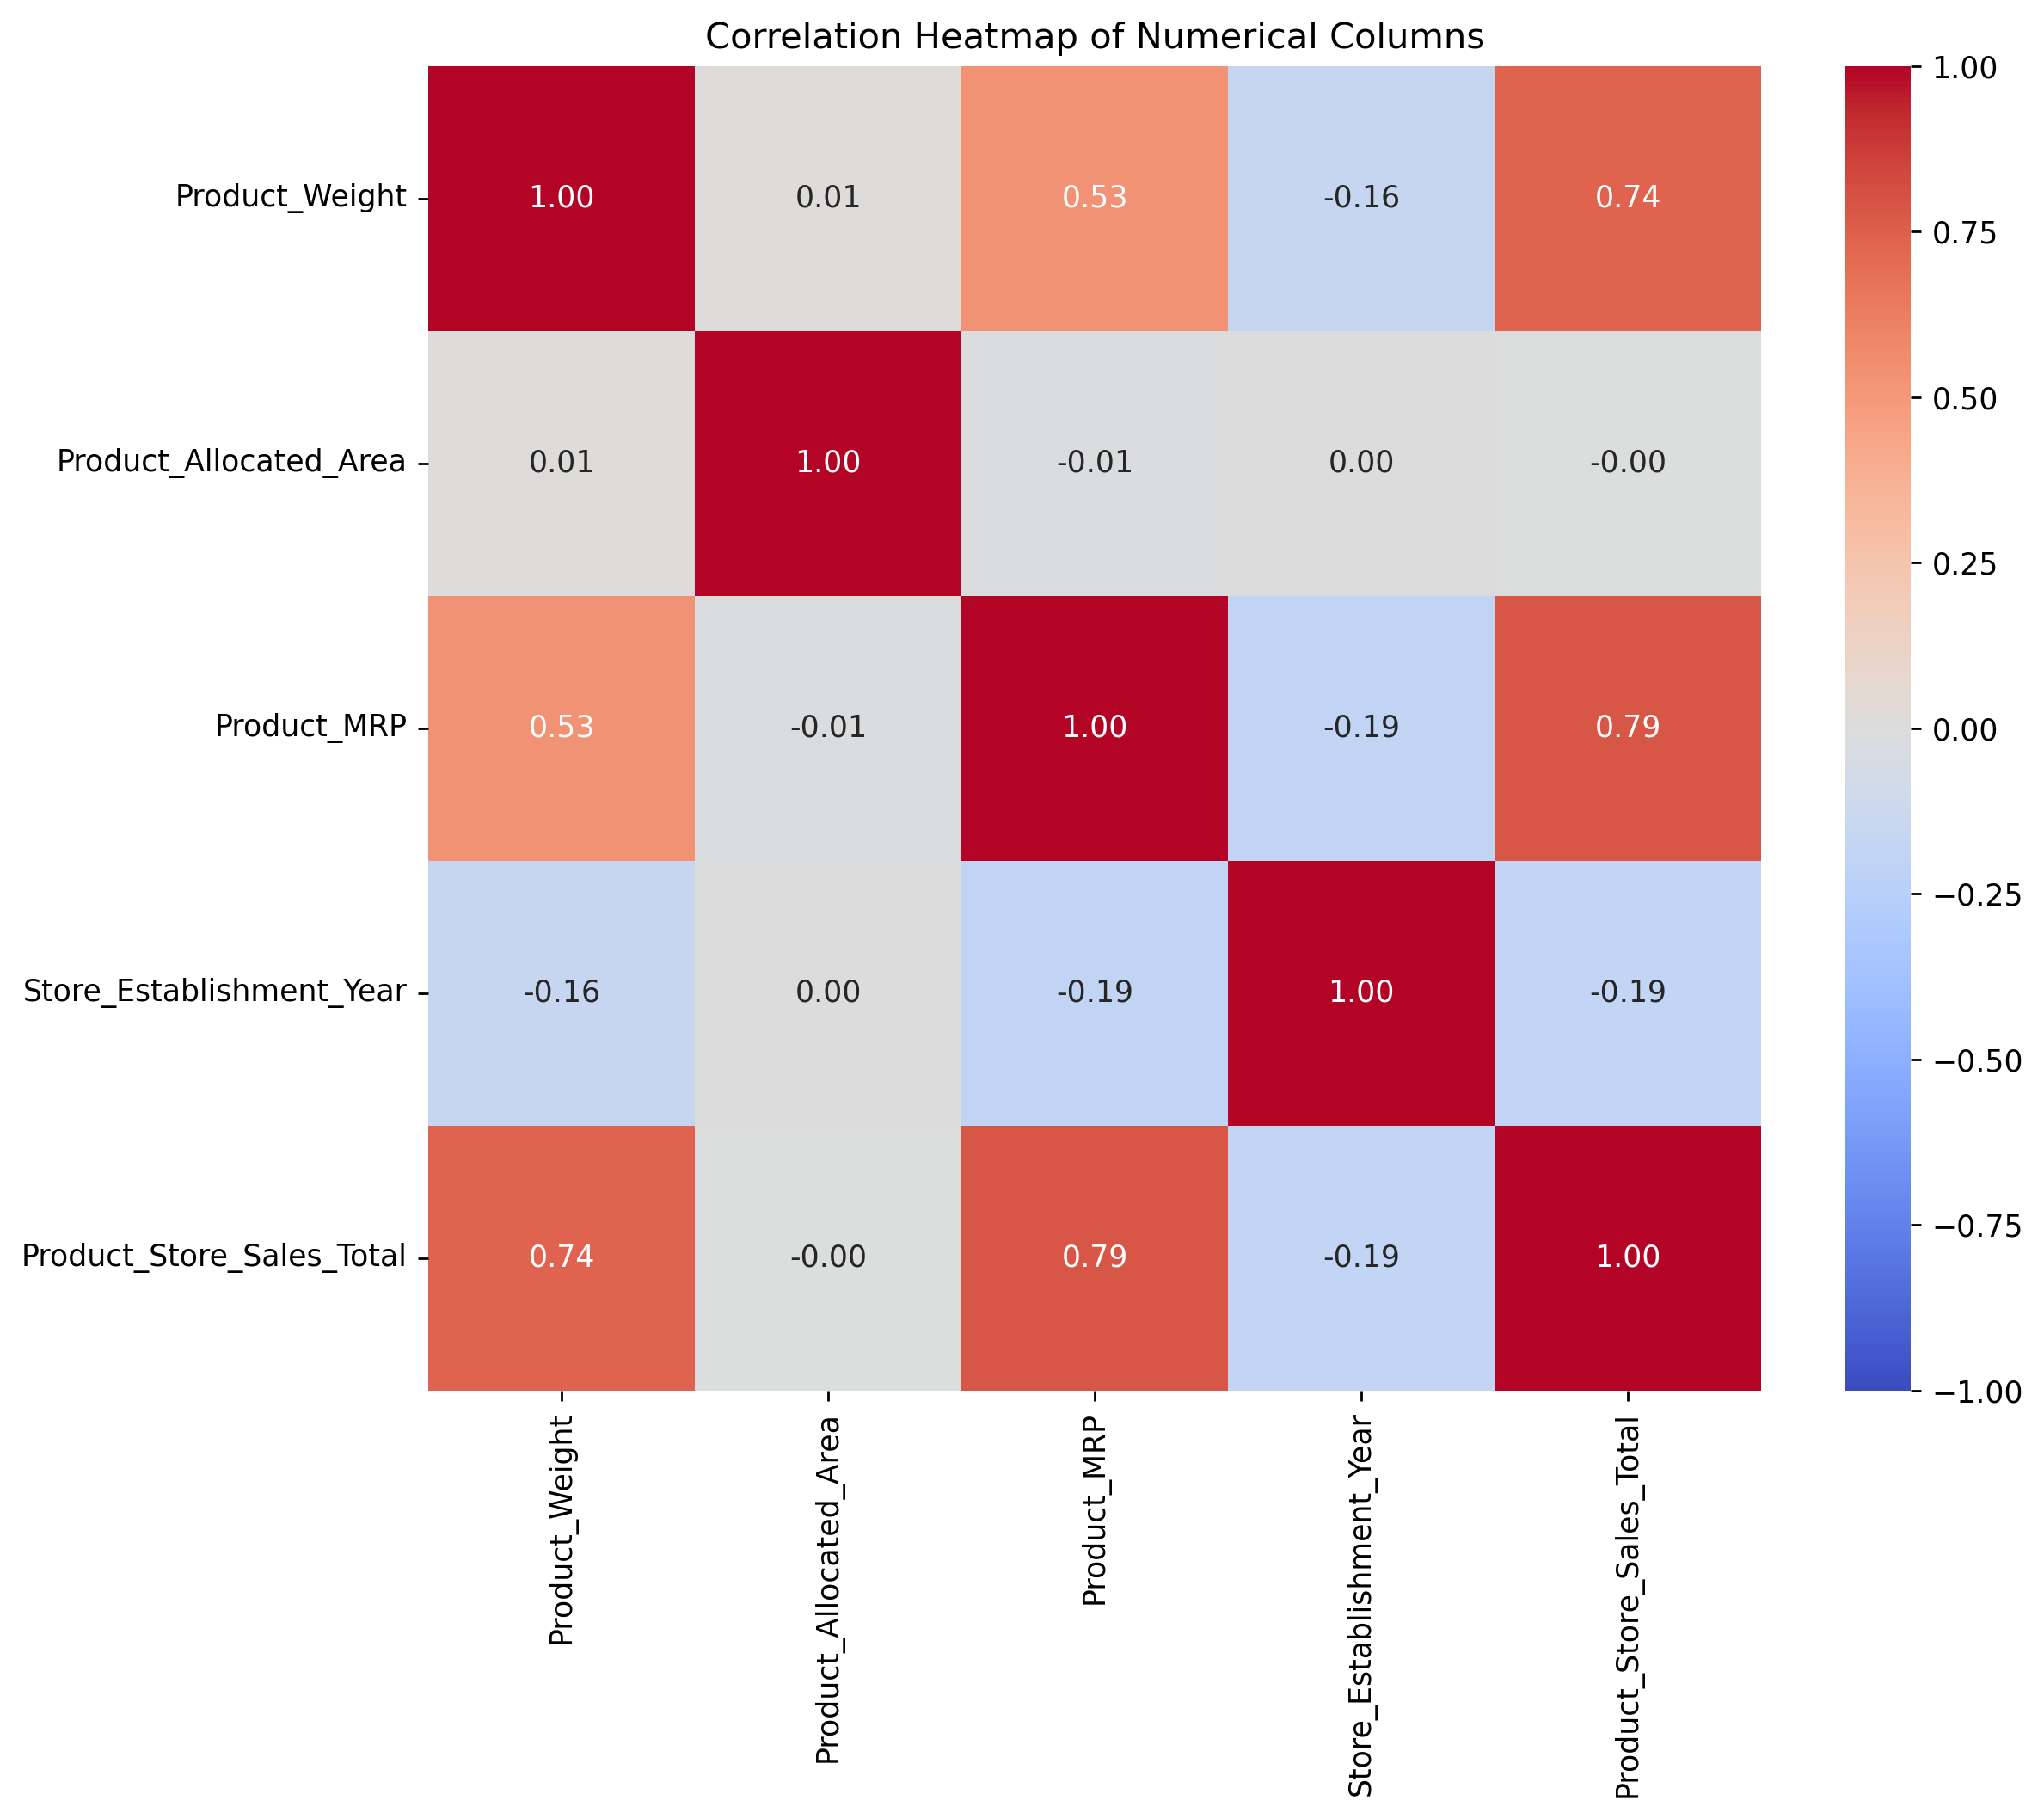

In [25]:
# Heat map of numerical colmuns
corr = base_df[num_cols].corr()
plt.figure(figsize=(10, 8), dpi=250)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

#### Multicollinearity Heatmap Review
- A review on a Heat Map of the correlation coefficients indicates that multicollinearity is not an issue with this dataset.
- The two items most strongly related to total sales are Product MRP at 0.79 and Product Weight at 0.74.
- There is also a minor relationship between Product MRP and Product Weight but I do not think this will be an issue. 
- Store year established has a minor negative correlation at -00.19.
- Product Allocaion Area has a zero correlation to total sales. Should this feature be dropped? Regualtzation? Check model results. 

<Figure size 2500x2000 with 0 Axes>

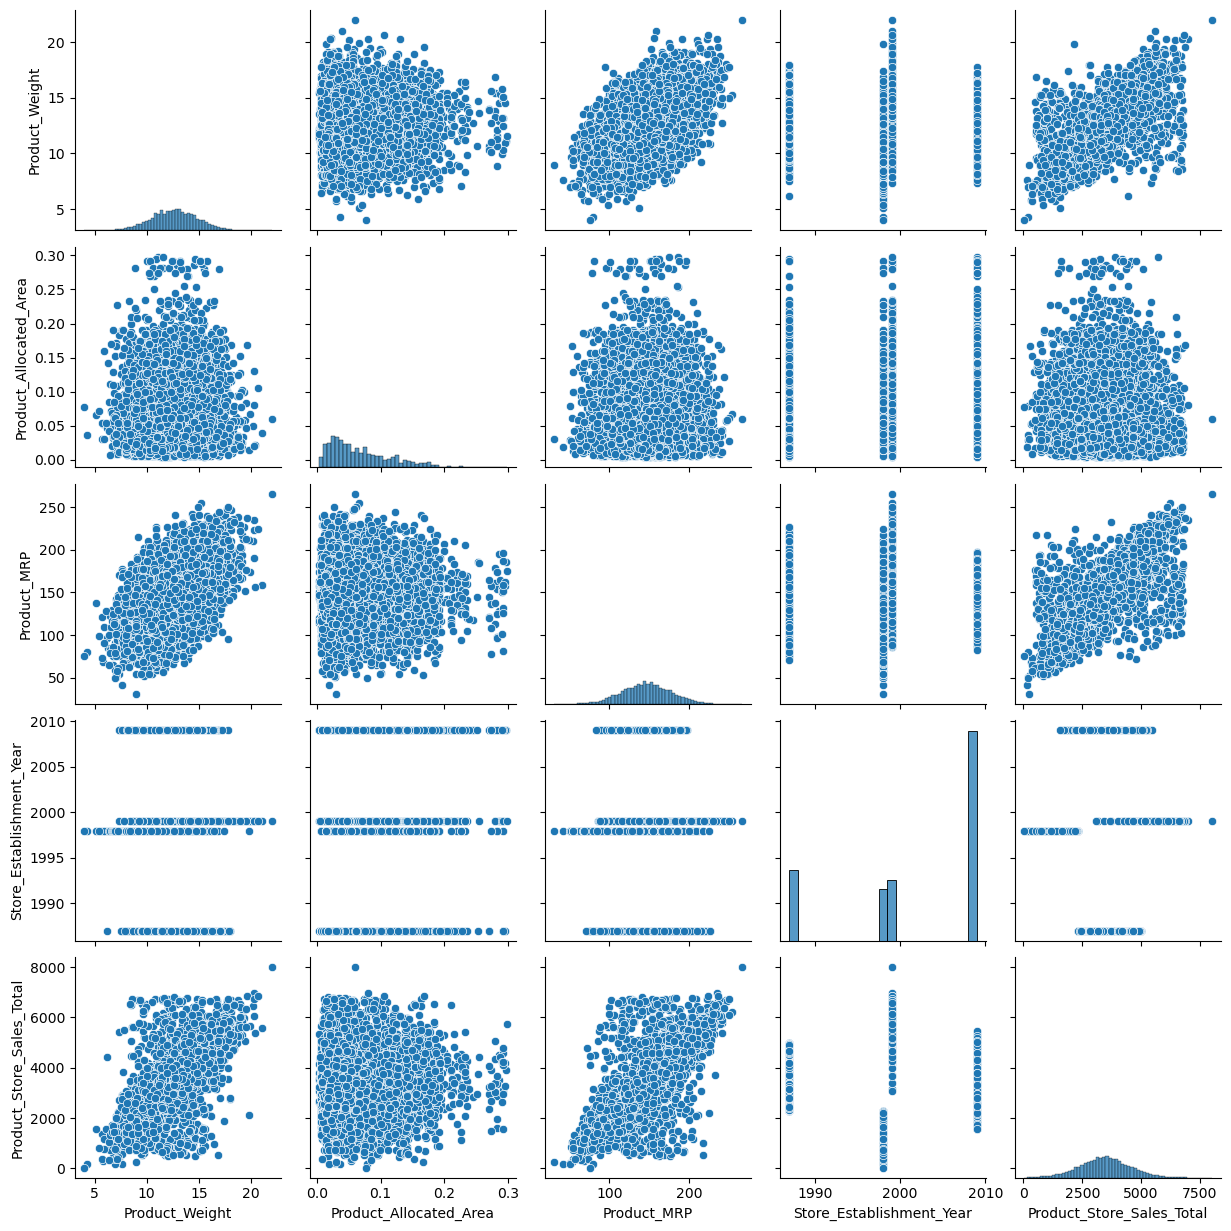

In [26]:
# pai plot of numerical colmuns
nums = base_df[num_cols]
plt.figure(figsize=(10, 8), dpi=250)
sns.pairplot(nums)
plt.show();

#### Pair Plot Analysis
- As suggested by the correlation matrix above there is a relationship between both Product MRP and Product Weight, and Total Sales.
- Any relationship between Product Allocated Area and Total Sales doesn't appear well in the plots. 

# **Data Preprocessing**

#### Fixing the Product_Sugar_Content Feature

In [27]:
base_df['Product_Sugar_Content'] = base_df['Product_Sugar_Content'].replace({'reg': 'Regular'})

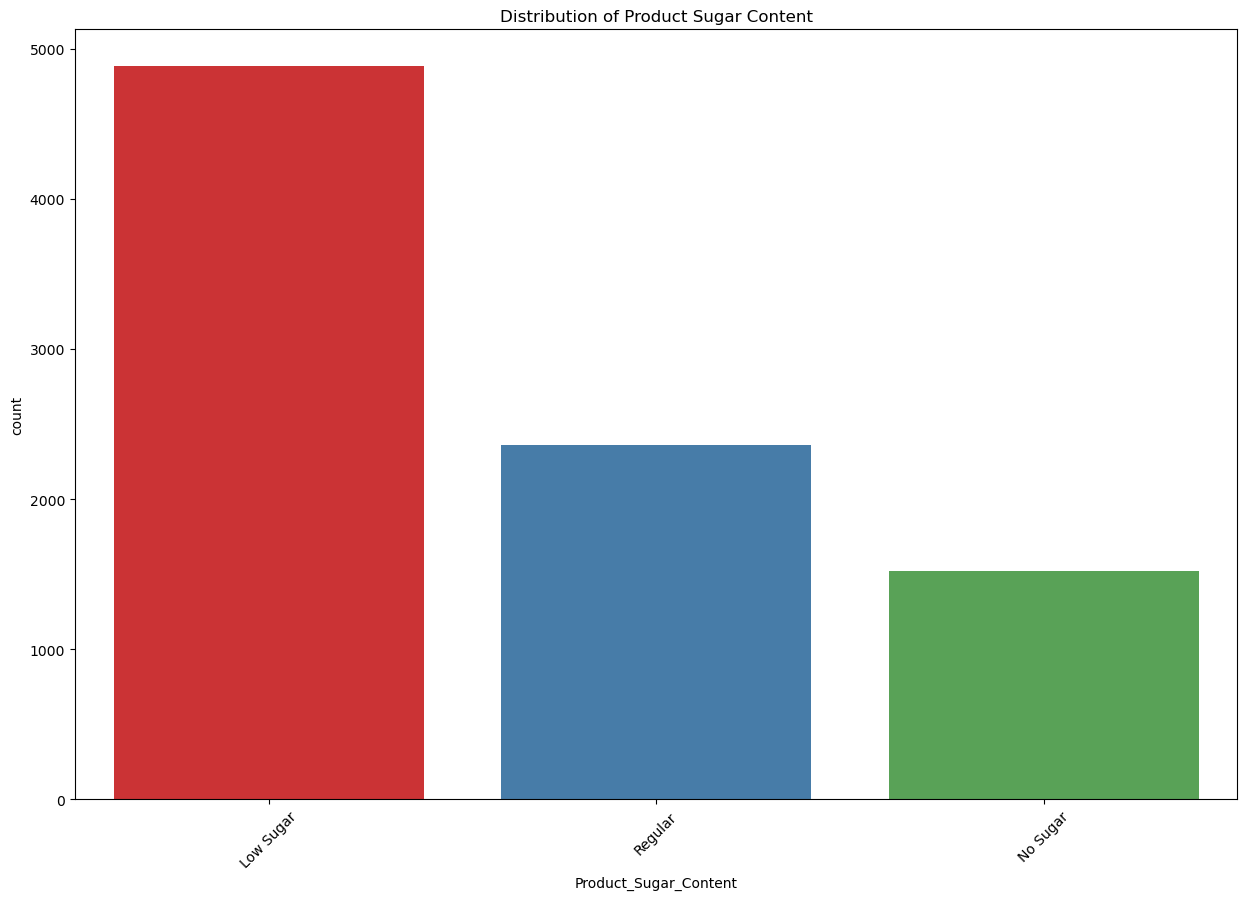

In [28]:
plt.figure(figsize=(15, 10))
sns.countplot(data=base_df, x='Product_Sugar_Content', palette="Set1")
plt.title(f"Distribution of Product Sugar Content")
plt.xticks(rotation=45) ;
# plt.show()

#### Capping Outliers

In [29]:
# creating a copy of the dataset as I start to make changes
df = base_df.copy()

In [30]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [31]:
# Outliers capped at 3 standard deviations
def cap_outliers(data, col):
    mean = data[col].mean()
    std = data[col].std()
    
    k=3
    lower_bound = mean - k * std
    upper_bound = mean + k * std
    
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])

In [32]:
cap_outliers(data=df, col='Product_Weight')

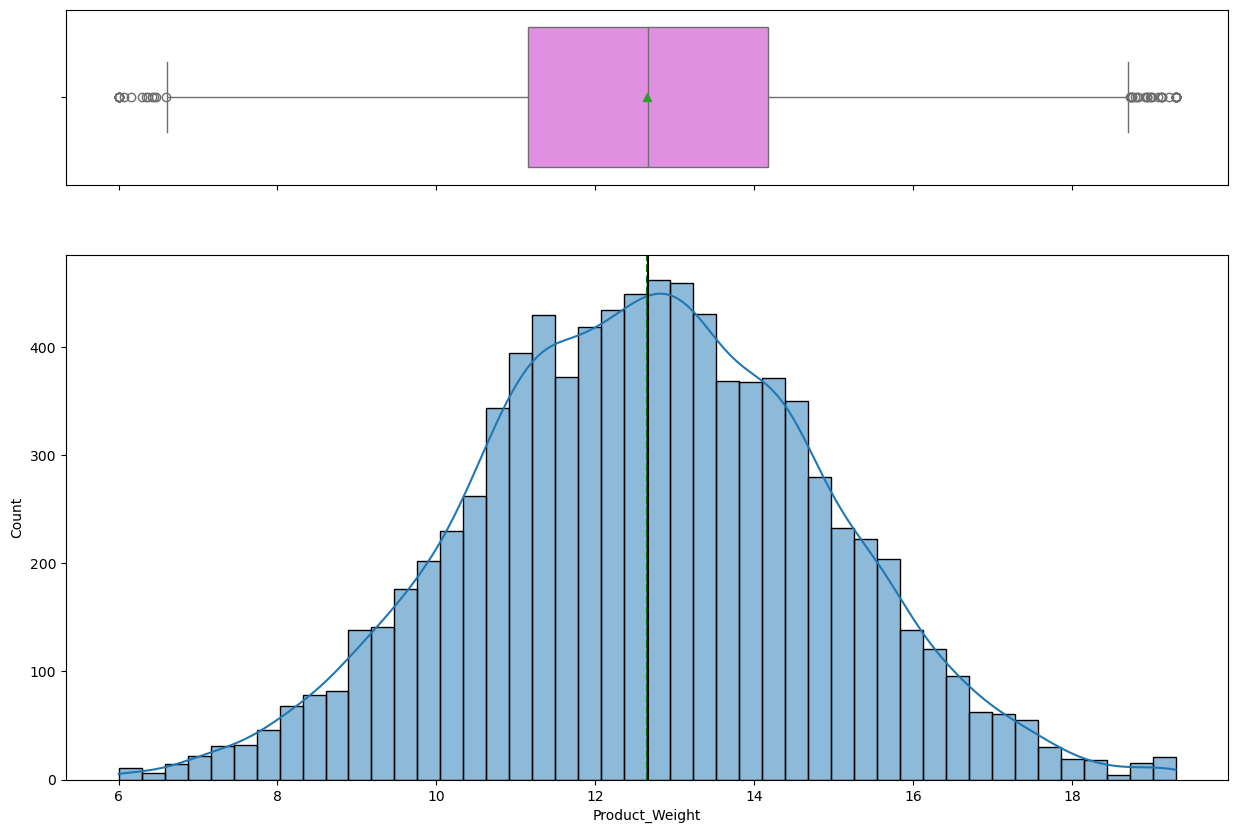

In [33]:
histogram_boxplot(data=df, feature='Product_Weight')

In [34]:
cap_outliers(data=df, col='Product_Allocated_Area')

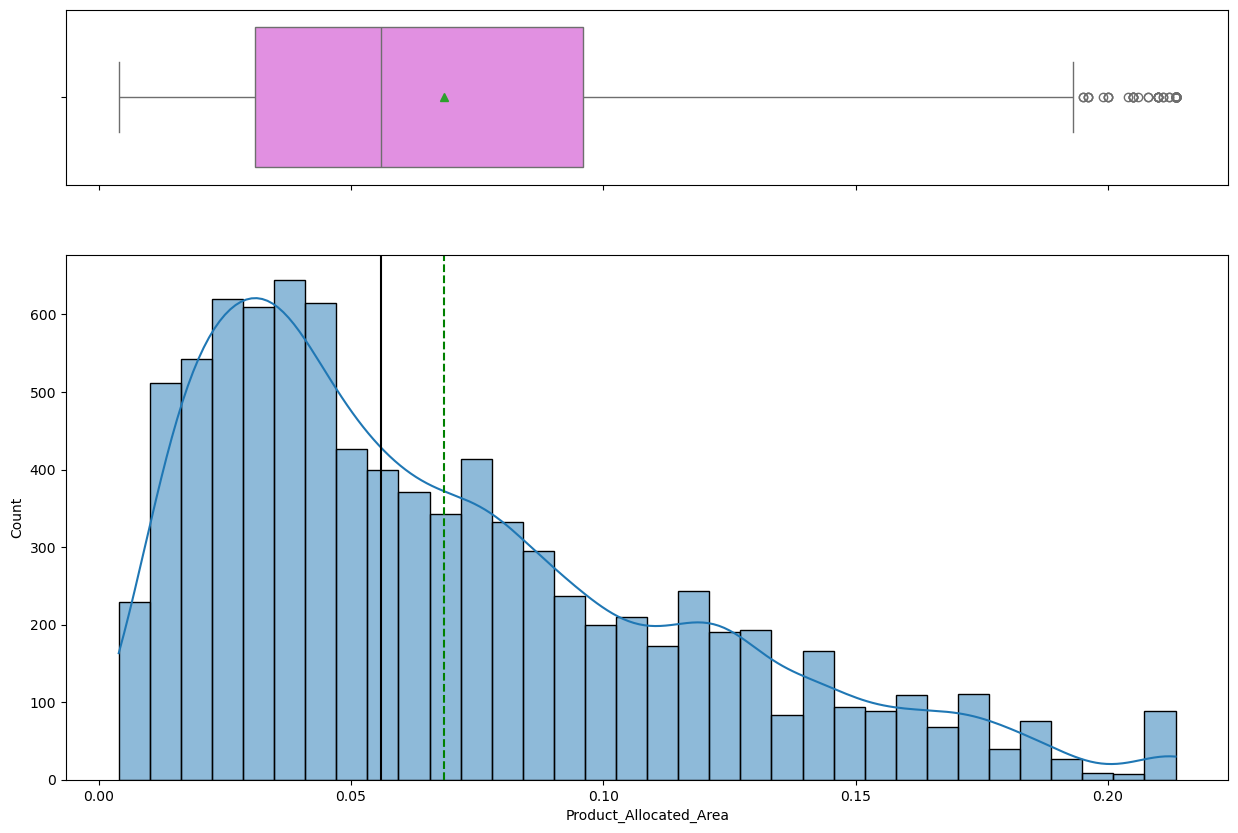

In [35]:
histogram_boxplot(data=df, feature='Product_Allocated_Area')

In [36]:
cap_outliers(data=df, col='Product_MRP')

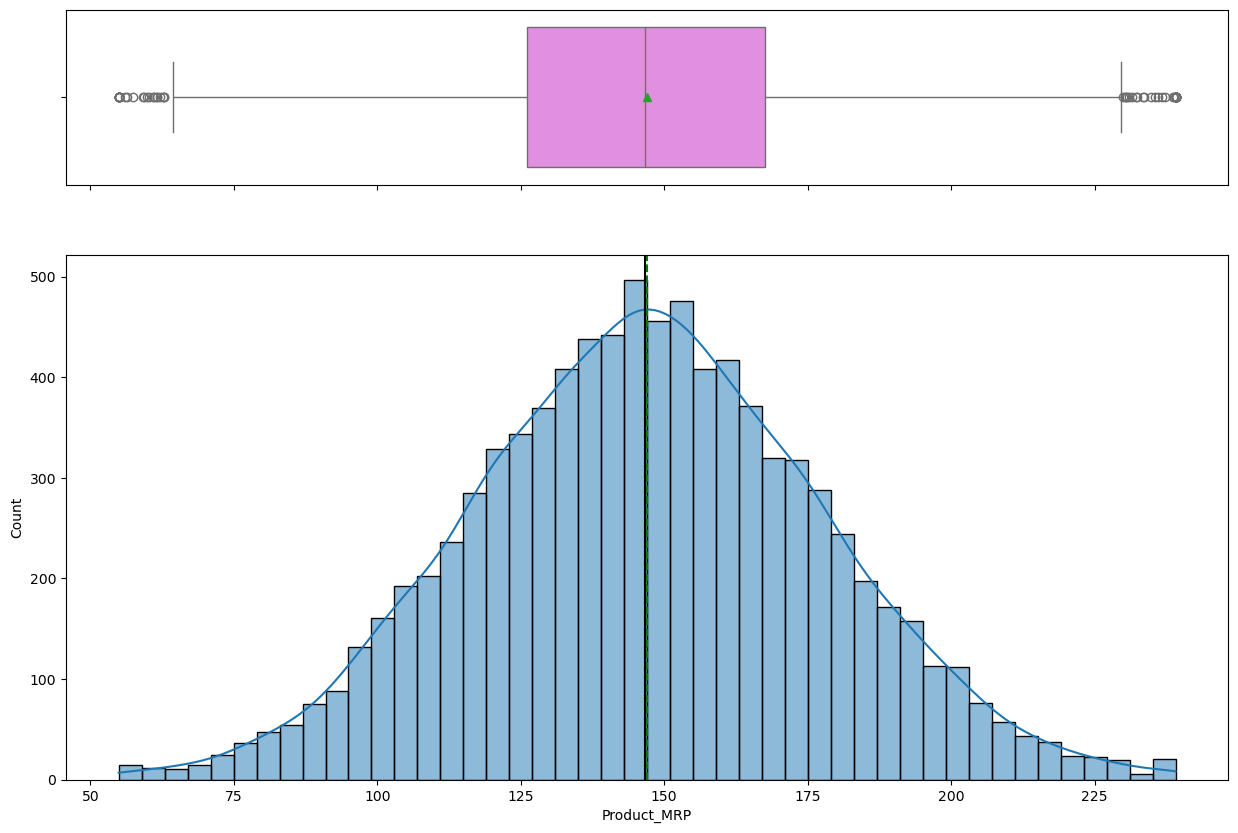

In [37]:
histogram_boxplot(data=df, feature='Product_MRP')

In [38]:
cap_outliers(data=df, col='Product_Store_Sales_Total')

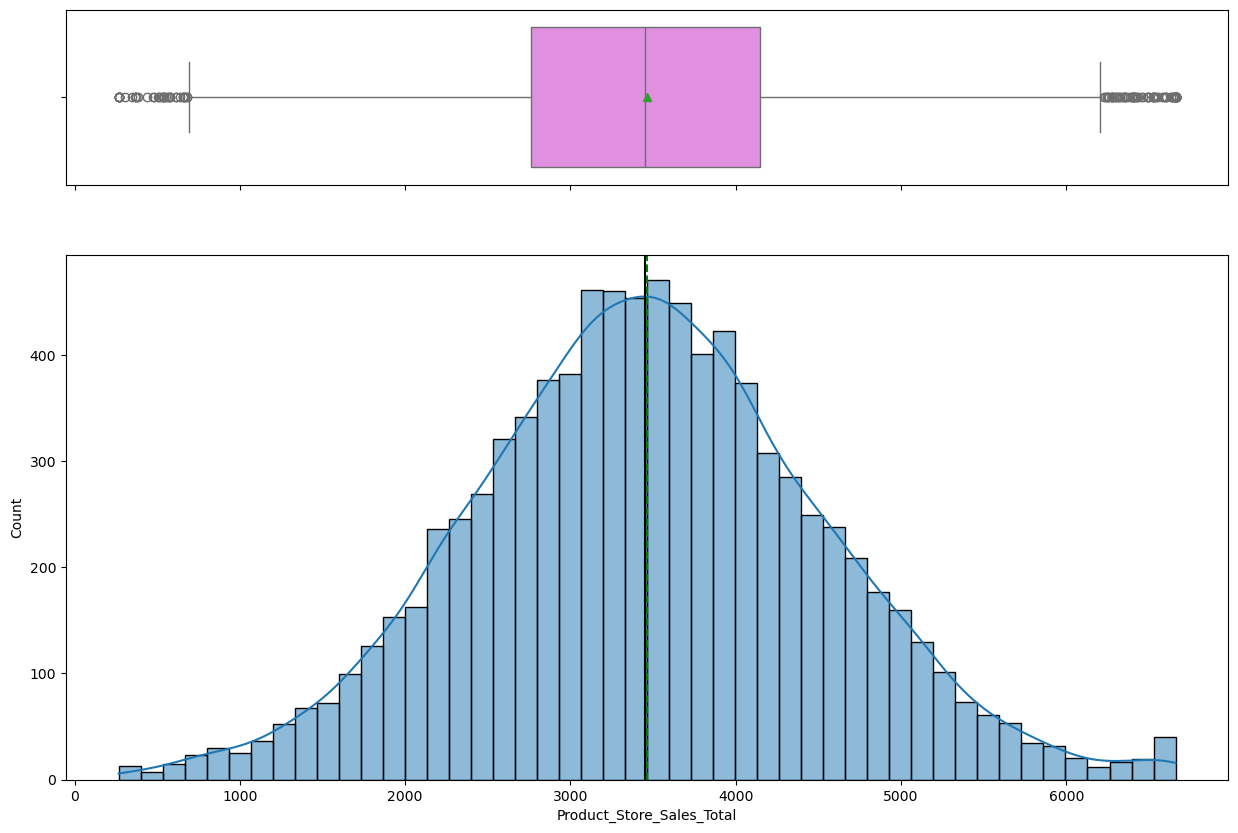

In [39]:
histogram_boxplot(data=df, feature='Product_Store_Sales_Total')

In [40]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


#### Group the Product Type Feature

In [41]:
df['Product_Type'].nunique()

16

In [42]:
df['Product_Type'].value_counts(dropna=False).head(50)

Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64

### Group Product Type into 4 types

In [43]:
# normalize capitalization if needed
df['Product_Type'] = df['Product_Type'].astype(str).str.strip()

MAP = {
    # drinks
    'Soft Drinks': 'drinks', 'Hard Drinks': 'drinks', 

    # perishable
    'Fruits and Vegetables': 'perishable', 'Frozen Foods': 'perishable', 'Dairy': 'perishable',
    'Meat': 'perishable', 'Seafood': 'perishable', 
    
    # nonperishable
    'Canned': 'nonperishable', 'Snack Foodsd': 'nonperishable', 'Baking Goods': 'nonperishable',
    'Breads': 'nonperishable', 'Starchy Foods': 'nonperishable', 'Breakfast': 'nonperishable',

    # others 
    'Household': 'others', 'Health and Hygiene': 'others', 'Others': 'others'
}

# ✅ apply map to the specific column
df['Product_Type_4'] = df['Product_Type'].map(MAP).fillna('others')

# optional: convert to categorical for efficiency
df['Product_Type_4'] = pd.Categorical(
    df['Product_Type_4'],
    categories=['drinks','perishable','nonperishable','others'],
    ordered=False
)


In [44]:
df.drop('Product_Type', axis=1, inplace=True)

In [45]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_4
0,FD6114,12.66,Low Sugar,0.027,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,perishable
1,FD7839,16.54,Low Sugar,0.144,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,perishable
2,FD5075,14.28,Regular,0.031,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,nonperishable
3,FD8233,12.10,Low Sugar,0.112,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,nonperishable
4,NC1180,9.57,No Sugar,0.010,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,others


### One Hot Encode Categorical Features

In [46]:
df = pd.get_dummies(
    df,
    columns=['Product_Sugar_Content'],
    prefix='Sugar',
    drop_first=True   
)


In [47]:
df.head()

,Product_Id,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_4,Sugar_No Sugar,Sugar_Regular
0,FD6114,12.66,0.027,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,perishable,False,False
1,FD7839,16.54,0.144,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,perishable,False,False
2,FD5075,14.28,0.031,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,nonperishable,False,True
3,FD8233,12.10,0.112,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,nonperishable,False,False
4,NC1180,9.57,0.010,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,others,True,False


In [48]:
df = pd.get_dummies(
    df,
    columns=['Product_Type_4'],
    prefix='Food_Cat',
    drop_first=True,
)

In [49]:
df.head()

,Product_Id,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Sugar_No Sugar,Sugar_Regular,Food_Cat_perishable,Food_Cat_nonperishable,Food_Cat_others
0,FD6114,12.66,0.027,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,False,False,True,False,False
1,FD7839,16.54,0.144,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,False,False,True,False,False
2,FD5075,14.28,0.031,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,False,True,False,True,False
3,FD8233,12.10,0.112,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,False,False,False,True,False
4,NC1180,9.57,0.010,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,True,False,False,False,True


In [50]:
df = pd.get_dummies(
    df,
    columns=['Store_Id'],
    prefix='Store',
    drop_first=True,
)

In [53]:
df.head()

,Product_Id,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Sugar_No Sugar,Sugar_Regular,Food_Cat_perishable,Food_Cat_nonperishable,Food_Cat_others,Store_OUT002,Store_OUT003,Store_OUT004
0,FD6114,12.66,0.027,117.08,2009,Medium,Tier 2,Supermarket Type2,2842.40,False,False,True,False,False,False,False,True
1,FD7839,16.54,0.144,171.43,1999,Medium,Tier 1,Departmental Store,4830.02,False,False,True,False,False,False,True,False
2,FD5075,14.28,0.031,162.08,1987,High,Tier 2,Supermarket Type1,4130.16,False,True,False,True,False,False,False,False
3,FD8233,12.10,0.112,186.31,1987,High,Tier 2,Supermarket Type1,4132.18,False,False,False,True,False,False,False,False
4,NC1180,9.57,0.010,123.67,1998,Small,Tier 3,Food Mart,2279.36,True,False,False,False,True,True,False,False


In [54]:
df = pd.get_dummies(
    df,
    columns=['Store_Size'],
    prefix='StoreSize',
    drop_first=True,
)

In [55]:
df.head()

,Product_Id,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Sugar_No Sugar,Sugar_Regular,Food_Cat_perishable,Food_Cat_nonperishable,Food_Cat_others,Store_OUT002,Store_OUT003,Store_OUT004,StoreSize_Medium,StoreSize_Small
0,FD6114,12.66,0.027,117.08,2009,Tier 2,Supermarket Type2,2842.40,False,False,True,False,False,False,False,True,True,False
1,FD7839,16.54,0.144,171.43,1999,Tier 1,Departmental Store,4830.02,False,False,True,False,False,False,True,False,True,False
2,FD5075,14.28,0.031,162.08,1987,Tier 2,Supermarket Type1,4130.16,False,True,False,True,False,False,False,False,False,False
3,FD8233,12.10,0.112,186.31,1987,Tier 2,Supermarket Type1,4132.18,False,False,False,True,False,False,False,False,False,False
4,NC1180,9.57,0.010,123.67,1998,Tier 3,Food Mart,2279.36,True,False,False,False,True,True,False,False,False,True


In [56]:
df = pd.get_dummies(
    df,
    columns=['Store_Location_City_Type'],
    prefix='City_Tier',
    drop_first=True,
)

In [57]:
df.head()

,Product_Id,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Store_Type,Product_Store_Sales_Total,Sugar_No Sugar,Sugar_Regular,Food_Cat_perishable,Food_Cat_nonperishable,Food_Cat_others,Store_OUT002,Store_OUT003,Store_OUT004,StoreSize_Medium,StoreSize_Small,City_Tier_Tier 2,City_Tier_Tier 3
0,FD6114,12.66,0.027,117.08,2009,Supermarket Type2,2842.40,False,False,True,False,False,False,False,True,True,False,True,False
1,FD7839,16.54,0.144,171.43,1999,Departmental Store,4830.02,False,False,True,False,False,False,True,False,True,False,False,False
2,FD5075,14.28,0.031,162.08,1987,Supermarket Type1,4130.16,False,True,False,True,False,False,False,False,False,False,True,False
3,FD8233,12.10,0.112,186.31,1987,Supermarket Type1,4132.18,False,False,False,True,False,False,False,False,False,False,True,False
4,NC1180,9.57,0.010,123.67,1998,Food Mart,2279.36,True,False,False,False,True,True,False,False,False,True,False,True


In [59]:
df = pd.get_dummies(
    df,
    columns=['Store_Type'],
    prefix='Store_Type',
    drop_first=True,
)

In [60]:
df.head()

,Product_Id,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total,Sugar_No Sugar,Sugar_Regular,Food_Cat_perishable,Food_Cat_nonperishable,Food_Cat_others,Store_OUT002,Store_OUT003,Store_OUT004,StoreSize_Medium,StoreSize_Small,City_Tier_Tier 2,City_Tier_Tier 3,Store_Type_Food Mart,Store_Type_Supermarket Type1,Store_Type_Supermarket Type2
0,FD6114,12.66,0.027,117.08,2009,2842.40,False,False,True,False,False,False,False,True,True,False,True,False,False,False,True
1,FD7839,16.54,0.144,171.43,1999,4830.02,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False
2,FD5075,14.28,0.031,162.08,1987,4130.16,False,True,False,True,False,False,False,False,False,False,True,False,False,True,False
3,FD8233,12.10,0.112,186.31,1987,4132.18,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False
4,NC1180,9.57,0.010,123.67,1998,2279.36,True,False,False,False,True,True,False,False,False,True,False,True,True,False,False


#### Drop Unwanted Columns

In [63]:
df.drop('Product_Id', axis=1, inplace=True)

In [64]:
df.drop('Store_Establishment_Year', axis=1, inplace=True)

In [65]:
df.head()

,Product_Weight,Product_Allocated_Area,Product_MRP,Product_Store_Sales_Total,Sugar_No Sugar,Sugar_Regular,Food_Cat_perishable,Food_Cat_nonperishable,Food_Cat_others,Store_OUT002,Store_OUT003,Store_OUT004,StoreSize_Medium,StoreSize_Small,City_Tier_Tier 2,City_Tier_Tier 3,Store_Type_Food Mart,Store_Type_Supermarket Type1,Store_Type_Supermarket Type2
0,12.66,0.027,117.08,2842.40,False,False,True,False,False,False,False,True,True,False,True,False,False,False,True
1,16.54,0.144,171.43,4830.02,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False
2,14.28,0.031,162.08,4130.16,False,True,False,True,False,False,False,False,False,False,True,False,False,True,False
3,12.10,0.112,186.31,4132.18,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False
4,9.57,0.010,123.67,2279.36,True,False,False,False,True,True,False,False,False,True,False,True,True,False,False


#### Separate Target and Features

In [71]:
y = df['Product_Store_Sales_Total']
X = df.drop('Product_Store_Sales_Total', axis=1)

#### Train, Validation, Test Split

In [73]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

In [74]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#### Scaling Data

# **Model Building**

## Define functions for Model Evaluation

In [51]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

# **Model Performance Improvement - Hyperparameter Tuning**

# **Model Performance Comparison, Final Model Selection, and Serialization**

# **Deployment - Backend**

## Flask Web Framework


## Dependencies File

## Dockerfile

## Setting up a Hugging Face Docker Space for the Backend

## Uploading Files to Hugging Face Space (Docker Space)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

## Dependencies File

## DockerFile

In [52]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Writing frontend_files/Dockerfile


FileNotFoundError: [Errno 2] No such file or directory: 'frontend_files/Dockerfile'

## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
end_time = time.time()
total_time = end_time - start_time
print(f"This noteboook took {total_time/60:.2f} to run.")

# **Actionable Insights and Business Recommendations**

-

-